# COMO Demo — Synthetic EGFR Series

This notebook walks through the full COMO pipeline on a 9-compound synthetic EGFR analog series (3×3 R-group grid: 3 R1 positions × 3 R2 positions on a quinazoline scaffold).

**Setup:** `pip install -e ..` from the repo root, or make sure `como` is on `sys.path`.

In [1]:
import sys
sys.path.insert(0, '..')   # if not installed via pip

import numpy as np
import polars as pl
from pathlib import Path

import como
print('como version:', getattr(como, '__version__', '0.1.0'))
print('como file:', como.__file__)

como version: 0.1.0
como file: /novo/users/vuln/como/notebooks/../como/__init__.py


## 1. Load the EA series

In [2]:
DATA = Path('../tests/data/synthetic_egfr.csv')
df = pl.read_csv(DATA)
print(df)

shape: (9, 2)
┌─────────────────────────────────┬───────────┐
│ smiles                          ┆ pActivity │
│ ---                             ┆ ---       │
│ str                             ┆ f64       │
╞═════════════════════════════════╪═══════════╡
│ COc1cc2ncnc(Nc3ccccc3)c2cc1OC   ┆ 7.2       │
│ COc1cc2ncnc(Nc3ccc(F)cc3)c2cc1… ┆ 7.8       │
│ COc1cc2ncnc(Nc3ccc(Cl)cc3)c2cc… ┆ 7.5       │
│ CCOc1cc2ncnc(Nc3ccccc3)c2cc1OC… ┆ 6.9       │
│ CCOc1cc2ncnc(Nc3ccc(F)cc3)c2cc… ┆ 7.4       │
│ CCOc1cc2ncnc(Nc3ccc(Cl)cc3)c2c… ┆ 7.1       │
│ Cc1cc2ncnc(Nc3ccccc3)c2cc1C     ┆ 6.5       │
│ Cc1cc2ncnc(Nc3ccc(F)cc3)c2cc1C  ┆ 7.0       │
│ Cc1cc2ncnc(Nc3ccc(Cl)cc3)c2cc1… ┆ 6.7       │
└─────────────────────────────────┴───────────┘


In [3]:
from rdkit import Chem
from rdkit.Chem import Draw

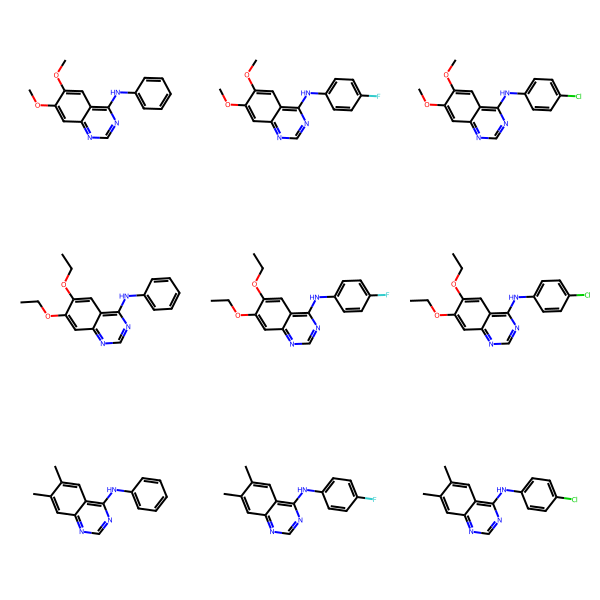

In [4]:
mols = [Chem.MolFromSmiles(s) for s in df['smiles']]
Draw.MolsToGridImage(mols)

In [5]:
mols[0].HasSubstructMatch(Chem.MolFromSmiles('N(C1=CC=CC=C1)C1=NC=NC2=CC=CC=C12'))

True

## 2. Run the full pipeline with `score_series`

All three VA strategies + an explicit scaffold. Writing outputs to `/tmp/como_demo/`.

In [6]:
OUTPUT = Path('/tmp/como_demo')
OUTPUT.mkdir(parents=True, exist_ok=True)

result = como.score_series(
    series_csv=DATA,
    smiles_col='smiles',
    activity_col='pActivity',
    # Explicit core = just the quinazoline ring system.
    # Omitting --core would auto-detect a Murcko scaffold that includes the anilino
    # group, which merges what should be R2 into the scaffold → 0 FW candidates.
    core='N(C1=CC=CC=C1)C1=NC=NC2=CC=CC=C12',
    va_strategies=['close_in', 'diverse', 'free_wilson'],
    va_n=1000,
    output_dir=OUTPUT,
)

print(f'C={result.C:.3f}  D={result.D:.3f}  S={result.S:.3f}  P={result.P:.3f}')
print(f'Stage: {result.stage}')
print(f'SVR CV  R²={result.cv_r2:.3f}  MAE={result.cv_mae:.3f}')
print(f'NBH radius (normalized 7D): {result.radius_used:.4f}')

[COMO] Input: 9 rows read  |  9 valid SMILES  |  9 unique  |  9 contain core
[COMO] EAs: 9  |  EAs in FW NBHs: 0 (0.0%)  |  FW sites: 3  |  Unique subs: 8
[COMO] C=0.021  D=0.636  S=0.040  P=0.354  stage=early
[COMO] Results written to /tmp/como_demo/
C=0.021  D=0.636  S=0.040  P=0.354
Stage: early
SVR CV  R²=0.643  MAE=0.175
NBH radius (normalized 7D): 0.9683


In [7]:
chembl2998 = pl.read_csv(Path('../tests/data/CHEMBL2998_CHEMBL3705123.csv'), separator=';', null_values=["None", ""])
chembl4296 = pl.read_csv(Path('../tests/data/CHEMBL4296_CHEMBL2328568.csv'), separator=';', null_values=["None", ""])

In [8]:
chembl2998.columns

['Molecule ChEMBL ID',
 'Molecule Name',
 'Molecule Max Phase',
 'Molecular Weight',
 '#RO5 Violations',
 'AlogP',
 'Compound Key',
 'Smiles',
 'Standard Type',
 'Standard Relation',
 'Standard Value',
 'Standard Units',
 'pChEMBL Value',
 'Data Validity Comment',
 'Comment',
 'Uo Units',
 'Ligand Efficiency BEI',
 'Ligand Efficiency LE',
 'Ligand Efficiency LLE',
 'Ligand Efficiency SEI',
 'Potential Duplicate',
 'Assay ChEMBL ID',
 'Assay Description',
 'Assay Type',
 'BAO Format ID',
 'BAO Label',
 'Assay Organism',
 'Assay Tissue ChEMBL ID',
 'Assay Tissue Name',
 'Assay Cell Type',
 'Assay Subcellular Fraction',
 'Assay Parameters',
 'Assay Variant Accession',
 'Assay Variant Mutation',
 'Target ChEMBL ID',
 'Target Name',
 'Target Organism',
 'Target Type',
 'Document ChEMBL ID',
 'Source ID',
 'Source Description',
 'Document Journal',
 'Document Year',
 'Cell ChEMBL ID',
 'Properties',
 'Action Type',
 'Standard Text Value',
 'Value']

In [9]:
result = como.score_series(
    series_csv=chembl2998,
    smiles_col='Smiles',
    activity_col='pChEMBL Value',
    core='*OC1=CC=CC=C1C1C(*)C(=O)C(=O)N1C1=CC=C(*)C(*)=C1',
    va_strategies=['close_in', 'diverse', 'free_wilson'],
    va_n=1000,
    output_dir=OUTPUT,
)

[COMO] Input: 752 rows read  |  751 valid SMILES  |  748 unique  |  281 contain core


[COMO] Warning: 3 EA(s) skipped — core match cuts a fused ring bond (core too small or molecule has extra fused rings). Consider using a larger core that includes the full fused system.
[COMO] Warning: 15 EA(s) rejected — substituents found outside the declared exit vector (*) positions in the core.
[COMO] Warning: 3 EA(s) skipped — core match cuts a fused ring bond (core too small or molecule has extra fused rings). Consider using a larger core that includes the full fused system.
[COMO] Warning: 15 EA(s) rejected — substituents found outside the declared exit vector (*) positions in the core.
[COMO] Warning: 3 EA(s) skipped — core match cuts a fused ring bond (core too small or molecule has extra fused rings). Consider using a larger core that includes the full fused system.
[COMO] Warning: 15 EA(s) rejected — substituents found outside the declared exit vector (*) positions in the core.


[COMO] EAs: 281  |  EAs in FW NBHs: 264 (94.0%)  |  FW sites: 4  |  Unique subs: 84
[COMO] C=0.192  D=0.642  S=0.296  P=0.545  stage=early_mid
[COMO] Results written to /tmp/como_demo/


In [10]:
result = como.score_series(
    series_csv=chembl4296,
    smiles_col='Smiles',
    activity_col='pChEMBL Value',
    core='ClC1=CC=C(OC2=CC=C(C=C2C#N)S(*)(=O)=O)C(*)=C1*',
    va_strategies=['close_in', 'diverse', 'free_wilson'],
    va_n=1000,
    output_dir=OUTPUT,
)

[COMO] Input: 1017 rows read  |  1017 valid SMILES  |  1017 unique  |  180 contain core


[COMO] Warning: 71 EA(s) rejected — substituents found outside the declared exit vector (*) positions in the core.
[COMO] Warning: 71 EA(s) rejected — substituents found outside the declared exit vector (*) positions in the core.
[COMO] Warning: 71 EA(s) rejected — substituents found outside the declared exit vector (*) positions in the core.


[COMO] EAs: 180  |  EAs in FW NBHs: 99 (55.0%)  |  FW sites: 3  |  Unique subs: 88
[COMO] C=0.059  D=0.584  S=0.107  P=0.882  stage=early_mid
[COMO] Results written to /tmp/como_demo/


## 3. Inspect VA populations

In [11]:
va_df = result.va_df
print('Total VAs:', len(va_df))
print()
print('VAs by strategy:')
print(va_df.group_by('source_strategy').agg(pl.len().alias('count')).sort('source_strategy'))

Total VAs: 2422

VAs by strategy:
shape: (3, 2)
┌─────────────────┬───────┐
│ source_strategy ┆ count │
│ ---             ┆ ---   │
│ str             ┆ u32   │
╞═════════════════╪═══════╡
│ close_in        ┆ 1000  │
│ diverse         ┆ 1000  │
│ free_wilson     ┆ 422   │
└─────────────────┴───────┘


In [12]:
# Top-10 VAs by predicted pActivity
top10 = (
    va_df
    .drop_nulls(subset=['pred_pActivity'])
    .sort('pred_pActivity', descending=True)
    .head(10)
    .select(['smiles', 'source_strategy', 'pred_pActivity', 'pActivity_percentile', 'in_nbh', 'nbh_count'])
)
print(top10)

shape: (10, 6)
┌─────────────────────┬─────────────────┬────────────────┬────────────────────┬────────┬───────────┐
│ smiles              ┆ source_strategy ┆ pred_pActivity ┆ pActivity_percenti ┆ in_nbh ┆ nbh_count │
│ ---                 ┆ ---             ┆ ---            ┆ le                 ┆ ---    ┆ ---       │
│ str                 ┆ str             ┆ f64            ┆ ---                ┆ bool   ┆ i64       │
│                     ┆                 ┆                ┆ f64                ┆        ┆           │
╞═════════════════════╪═════════════════╪════════════════╪════════════════════╪════════╪═══════════╡
│ N#Cc1cc(S(=O)(=O)Nc ┆ free_wilson     ┆ 8.953213       ┆ 99.213373          ┆ false  ┆ 0         │
│ 2ncc(Cl)s2)…        ┆                 ┆                ┆                    ┆        ┆           │
│ N#Cc1cc(S(=O)(=O)Nc ┆ free_wilson     ┆ 8.813102       ┆ 98.525074          ┆ true   ┆ 1         │
│ 2nccs2)ccc1…        ┆                 ┆                ┆                  

In [13]:
# Free-Wilson VAs and their additivity predictions
fw_df = va_df.filter(pl.col('source_strategy') == 'free_wilson')
print('FW VAs:', len(fw_df))
if len(fw_df) > 0:
    print(fw_df.select(['smiles', 'fw_pred_pActivity', 'pred_pActivity']))

FW VAs: 422
shape: (422, 3)
┌─────────────────────────────────┬───────────────────┬────────────────┐
│ smiles                          ┆ fw_pred_pActivity ┆ pred_pActivity │
│ ---                             ┆ ---               ┆ ---            │
│ str                             ┆ f64               ┆ f64            │
╞═════════════════════════════════╪═══════════════════╪════════════════╡
│ N#Cc1cc(S(=O)(=O)Nc2ccc(F)cn2)… ┆ 5.245             ┆ 6.103528       │
│ N#Cc1cc(S(=O)(=O)Nc2ccc(F)cn2)… ┆ 4.94              ┆ 5.801046       │
│ N#Cc1cc(S(=O)(=O)Nc2ccc(F)cn2)… ┆ 4.94              ┆ 5.677008       │
│ N#Cc1cc(S(=O)(=O)Nc2ccc(F)cn2)… ┆ 5.353333          ┆ 6.154497       │
│ N#Cc1cc(S(=O)(=O)Nc2ccc(F)cn2)… ┆ 5.7               ┆ 6.318145       │
│ …                               ┆ …                 ┆ …              │
│ N#Cc1cc(S(=O)(=O)Nc2nccs2)ccc1… ┆ 6.36              ┆ 5.732262       │
│ N#Cc1cc(S(=O)(=O)Nc2nccs2)ccc1… ┆ 6.38              ┆ 5.434354       │
│ Cn1nccc1-c1c(Cl)ccc(O

## 4. Read the output files

In [14]:
scores = pl.read_csv(OUTPUT / 'scores.csv')
print(scores)

shape: (15, 2)
┌──────────────────────────┬────────┐
│ metric                   ┆ value  │
│ ---                      ┆ ---    │
│ str                      ┆ str    │
╞══════════════════════════╪════════╡
│ C                        ┆ 0.0590 │
│ D                        ┆ 0.5843 │
│ d_mean                   ┆ 2.4056 │
│ S                        ┆ 0.1072 │
│ P                        ┆ 0.8821 │
│ …                        ┆ …      │
│ cv_mae                   ┆ 0.4022 │
│ fw_n_candidates          ┆ 422    │
│ fw_n_ea_in_nbh           ┆ 99     │
│ fw_n_sites               ┆ 3      │
│ fw_n_unique_substituents ┆ 88     │
└──────────────────────────┴────────┘


In [15]:
print((OUTPUT / 'summary.txt').read_text())

COMO / DeepCOMO Analog Series Analysis

--- Analog Series Statistics ---
  EAs (existing analogs):   1017
  Valid EAs (parsed):       1017
  pActivity range:          4.27 – 9.22
  pActivity mean ± std:     6.55 ± 1.09

--- Chemical Space Parameters ---
  NBH radius (r):           0.2002 (normalized 7D space)
  Descriptors:              MW, LogP, TPSA, HBD, HBA, RotBonds, Rings

--- COMO Scores ---
  C (coverage):             0.0590
    → Fraction of VAs falling into at least one EA neighborhood.
      High C = VAs cover well-explored EA chemical space.
  D (density):              0.5843  (d_mean = 2.4056)
    → Overlap density of EA neighborhoods by VAs.
      High D = VAs densely map EA-local chemical space.
  S (saturation):           0.1072  [harmonic mean of C and D]
    → Overall chemical saturation score.
  P (SAR progression):      0.8821
    → SAR discontinuity in overlapping EA neighborhoods.
      High P = large potency variations among structurally similar EAs.

--- Develop

## 5. Use individual score functions directly

Useful for recomputing scores with a custom membership matrix or different thresholds.

In [16]:
from como import c_score, d_score, s_score, p_score, assign_stage
from como.descriptors import compute_descriptors, normalize_descriptors
from como.nbh import build_nbh

ea_smiles = df['smiles'].to_list()
ea_activities = df['pActivity'].to_numpy()

# Generate a small set of VAs manually
from como.analogs.close_in import CloseInVAGenerator
gen = CloseInVAGenerator()
va_smiles = gen.generate(
    ea_smiles, ea_activities,
    core_smiles='c1cc2ncncc2cc1',
    n=1000,
    ea_hac_range=(10, 50),
)
print(f'{len(va_smiles)} close-in VAs generated')

# Compute descriptors + normalize on combined EA+VA population
ea_raw, _ = compute_descriptors(ea_smiles)
va_raw, _ = compute_descriptors(va_smiles)
ea_norm, va_norm, scaler = normalize_descriptors(ea_raw, va_raw)

# Build neighborhood membership matrix
membership, radius = build_nbh(ea_norm, va_norm)  # adaptive radius
print(f'NBH radius: {radius:.4f}')
print(f'membership shape: {membership.shape}  (n_va × n_ea)')

18 close-in VAs generated
NBH radius: 1.7892
membership shape: (18, 9)  (n_va × n_ea)


In [17]:
C = c_score(membership)
D, d_mean = d_score(membership)
S = s_score(C, D)
P = p_score(membership, ea_activities)
stage = assign_stage(S, P)

print(f'C = {C:.4f}  (fraction of VAs in ≥1 EA neighborhood)')
print(f'D = {D:.4f}  (d_mean = {d_mean:.4f})')
print(f'S = {S:.4f}  (harmonic mean of C and D)')
print(f'P = {P:.4f}  (SAR progression)')
print(f'Stage: {stage}')

C = 0.3333  (fraction of VAs in ≥1 EA neighborhood)
D = 0.7500  (d_mean = 4.0000)
S = 0.4615  (harmonic mean of C and D)
P = 0.4389  (SAR progression)
Stage: mid


## 6. Plug-in hook: supply VAs from any generative model

Write a CSV with a `smiles` column (and optionally a predicted activity column) and pass it to `score_series` via `va_csv=`. The CSV plugin passes those molecules through as a `csv_plugin` strategy in the VA population.

In [18]:
import csv, tempfile

# Simulate a generative model output: write a small CSV with a custom activity column.
gen_smiles = [
    ('COc1cc2ncnc(Nc3ccc(Br)cc3)c2cc1OC',  7.9),
    ('CCOc1cc2ncnc(Nc3ccc(Br)cc3)c2cc1OCC', 7.6),
    ('Cc1cc2ncnc(Nc3ccc(F)cc3)c2cc1C',      6.8),
]

tmp_csv = Path(tempfile.mktemp(suffix='.csv'))
with open(tmp_csv, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['smiles', 'pred_pAct'])
    writer.writerows(gen_smiles)

result_gen = como.score_series(
    series_csv=DATA,
    core='c1cc2ncncc2cc1',
    va_strategies=['close_in'],
    va_csv=tmp_csv,
    va_csv_activity_col='pred_pAct',   # tells COMO which column holds the model's predictions
    va_n=1000,
    output_dir=OUTPUT / 'gen_run',
)

plugin_rows = result_gen.va_df.filter(pl.col('source_strategy') == 'csv_plugin')
print('CSV plugin VAs:', len(plugin_rows))
# external_pred_pActivity carries the generative model's own predicted values
print(plugin_rows.select(['smiles', 'pred_pActivity', 'external_pred_pActivity', 'in_nbh']))

[COMO] Input: 9 rows read  |  9 valid SMILES  |  9 unique  |  9 contain core
[COMO] EAs: 9  |  EAs in FW NBHs: 0 (0.0%)  |  FW sites: 0  |  Unique subs: 0
[COMO] C=0.400  D=0.692  S=0.507  P=0.439  stage=mid
[COMO] Results written to /tmp/como_demo/gen_run/
CSV plugin VAs: 2
shape: (2, 4)
┌─────────────────────────────────┬────────────────┬─────────────────────────┬────────┐
│ smiles                          ┆ pred_pActivity ┆ external_pred_pActivity ┆ in_nbh │
│ ---                             ┆ ---            ┆ ---                     ┆ ---    │
│ str                             ┆ f64            ┆ f64                     ┆ bool   │
╞═════════════════════════════════╪════════════════╪═════════════════════════╪════════╡
│ COc1cc2ncnc(Nc3ccc(Br)cc3)c2cc… ┆ 7.432395       ┆ 7.9                     ┆ true   │
│ CCOc1cc2ncnc(Nc3ccc(Br)cc3)c2c… ┆ 7.182969       ┆ 7.6                     ┆ true   │
└─────────────────────────────────┴────────────────┴─────────────────────────┴────────┘


## 7. Visualise score space (optional)

Place each series in the S–P plane to see its development stage.

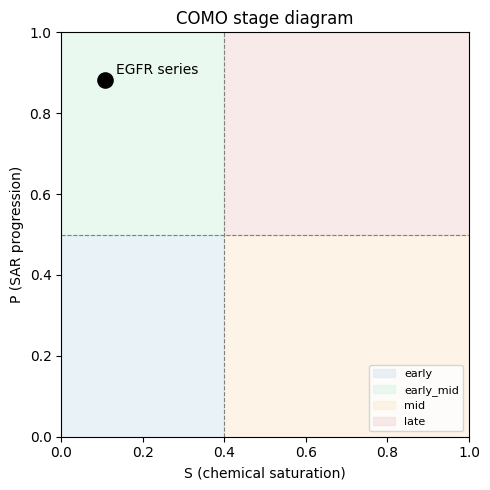

In [19]:
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(5, 5))

    # Stage quadrant shading
    ax.axhline(0.5, color='grey', lw=0.8, ls='--')
    ax.axvline(0.4, color='grey', lw=0.8, ls='--')
    for (x0, x1, y0, y1, label, color) in [
        (0,   0.4, 0,   0.5, 'early',      '#d4e6f1'),
        (0,   0.4, 0.5, 1.0, 'early_mid',  '#d5f5e3'),
        (0.4, 1.0, 0,   0.5, 'mid',        '#fdebd0'),
        (0.4, 1.0, 0.5, 1.0, 'late',       '#f2d7d5'),
    ]:
        ax.fill_between([x0, x1], [y0, y0], [y1, y1], color=color, alpha=0.5, label=label)

    ax.scatter(result.S, result.P, s=120, zorder=5, color='black')
    ax.annotate('EGFR series', (result.S, result.P), textcoords='offset points', xytext=(8, 4))

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('S (chemical saturation)')
    ax.set_ylabel('P (SAR progression)')
    ax.set_title('COMO stage diagram')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib not available — skipping plot')